# Ablation Stage 2: ConvNeXt-Tiny + Vision Mamba

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (17).zip to archive (17).zip


## Imports & configuration

In [ ]:
import os
import re
import shutil
import hashlib
import zipfile

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report,
)
import matplotlib.pyplot as plt

RANDOM_SEED = 42
IMG_SIZE = (224, 224)

## Extract dataset

In [ ]:

ZIP_PATH = "/content/archive (17).zip"
EXTRACT_DIR = "/content/brain_ct_extracted"
OUTPUT_DIR = "/content/patient_level_dataset"

MANIFEST_PATH = "/content/patient_level_split_manifest.csv"
CASE_MANIFEST_PATH = "/content/case_level_split_manifest.csv"

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")
print("Location:", EXTRACT_DIR)

image_files = [
    os.path.join(root, file)
    for root, _, files_in_dir in os.walk(EXTRACT_DIR)
    for file in files_in_dir
    if file.lower().endswith(IMAGE_EXTENSIONS)
]
print("Total image files found:", len(image_files))



Dataset extracted successfully.
Location: /content/brain_ct_extracted
Total image files found: 2515


## Parse class and patient (case) ID



In [ ]:

def extract_class(path):

    parts = os.path.normpath(path).split(os.sep)
    for part in parts:
        if part.lower() in ["normal", "stroke"]:
            return part.capitalize()
    return None


def extract_case_id(filename):

    match = re.match(r"^\s*(\d+)", filename)
    return match.group(1) if match else None


records = []
for path in image_files:
    filename = os.path.basename(path)
    class_name = extract_class(path)
    case_id = extract_case_id(filename)
    if class_name is None or case_id is None:
        continue
    records.append({
        "image_path": path, "filename": filename,
        "class": class_name, "case_id": case_id,
    })

df = pd.DataFrame(records)
print("Valid image records:", len(df))
print(df.groupby("class")["case_id"].nunique())



Valid image records: 2515
class
Normal    51
Stroke    31
Name: case_id, dtype: int64


In [ ]:

def calculate_sha256(filepath):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()


df["sha256"] = df["image_path"].apply(calculate_sha256)
df["duplicate_of"] = ""
first_occurrence = {}
for index, row in df.iterrows():
    h = row["sha256"]
    if h in first_occurrence:
        df.at[index, "duplicate_of"] = first_occurrence[h]
    else:
        first_occurrence[h] = row["image_path"]

df_unique = df[df["duplicate_of"] == ""].copy()
print("Unique images:", len(df_unique))
print("Unique patients:", df_unique[["class", "case_id"]].drop_duplicates().shape[0])



Unique images: 2501
Unique patients: 82


## Patient-level train / validation / test split



In [ ]:

case_df = df_unique[["class", "case_id"]].drop_duplicates().reset_index(drop=True)

train_val_cases, test_cases = train_test_split(
    case_df, test_size=17, stratify=case_df["class"], random_state=RANDOM_SEED,
)
train_cases, val_cases = train_test_split(
    train_val_cases, test_size=8, stratify=train_val_cases["class"], random_state=RANDOM_SEED,
)

print("Training patients   :", len(train_cases))
print("Validation patients :", len(val_cases))
print("Testing patients    :", len(test_cases))

train_case_set = set(zip(train_cases["class"], train_cases["case_id"]))
val_case_set = set(zip(val_cases["class"], val_cases["case_id"]))
test_case_set = set(zip(test_cases["class"], test_cases["case_id"]))


def assign_split(row):
    key = (row["class"], row["case_id"])
    if key in train_case_set:
        return "Train"
    if key in val_case_set:
        return "Validation"
    if key in test_case_set:
        return "Test"
    return None


df_unique["corrected_split"] = df_unique.apply(assign_split, axis=1)

train_ids = set(train_cases["case_id"])
val_ids = set(val_cases["case_id"])
test_ids = set(test_cases["case_id"])
assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids)
print("Patient overlap check passed — zero overlap between splits.")

train_df = df_unique[df_unique["corrected_split"] == "Train"].reset_index(drop=True)
val_df = df_unique[df_unique["corrected_split"] == "Validation"].reset_index(drop=True)
test_df = df_unique[df_unique["corrected_split"] == "Test"].reset_index(drop=True)
print("Train:", len(train_df), " Validation:", len(val_df), " Test:", len(test_df))


Training patients   : 57
Validation patients : 8
Testing patients    : 17
Patient overlap check passed — zero overlap between splits.
Train: 1761  Validation: 221  Test: 519


In [ ]:
for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    normal = (data["class"] == "Normal").sum()
    stroke = (data["class"] == "Stroke").sum()

    print(
        f"{name}: "
        f"Total = {len(data)}, "
        f"Normal = {normal}, "
        f"Stroke = {stroke}, "
        f"Patients = {data['case_id'].nunique()}"
    )

Train: Total = 1761, Normal = 1065, Stroke = 696, Patients = 57
Validation: Total = 221, Normal = 148, Stroke = 73, Patients = 8
Test: Total = 519, Normal = 338, Stroke = 181, Patients = 17


## Verify zero patient overlap between splits

In [ ]:
train_ids = set(train_cases["case_id"])
val_ids = set(val_cases["case_id"])
test_ids = set(test_cases["case_id"])

print("Train ∩ Validation:", train_ids & val_ids)
print("Train ∩ Test:      ", train_ids & test_ids)
print("Validation ∩ Test: ", val_ids & test_ids)

Train ∩ Validation: set()
Train ∩ Test:       set()
Validation ∩ Test:  set()


## Preprocessing pipeline

In [ ]:
def resize_image(image, size=(224, 224)):
    return cv2.resize(image, size, interpolation=cv2.INTER_AREA)


def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    gray = image[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced = clahe.apply(gray)
    return np.stack([enhanced] * 3, axis=-1)


def apply_gamma_correction(image, gamma=1.2):
    img_float = image.astype(np.float32) / 255.0
    gamma_corrected = np.power(img_float, gamma)
    return (gamma_corrected * 255.0).astype(np.uint8)


def normalize_image(image):
    return image.astype(np.float32) / 255.0


def preprocess_pipeline(image):
    """Resize -> CLAHE -> gamma correction (gamma=1.2) -> normalize to [0,1]."""
    resized = resize_image(image)
    clahe_img = apply_clahe(resized)
    gamma_img = apply_gamma_correction(clahe_img, gamma=1.2)
    normalized = normalize_image(gamma_img)
    return resized, clahe_img, gamma_img, normalized

## Augmentation

In [ ]:

train_augmenter = keras.Sequential([
    layers.RandomRotation(factor=8 / 360, fill_mode="constant"),
    layers.RandomZoom(height_factor=(-0.15, 0.15), fill_mode="constant"),
    layers.RandomContrast(factor=0.2),
], name="online_augmentation")


def _load_and_preprocess(path, label):
    def _run(p):
        raw = cv2.imread(p.numpy().decode("utf-8"))
        raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        _, _, _, normalized = preprocess_pipeline(raw)
        return normalized.astype(np.float32)

    image = tf.py_function(func=_run, inp=[path], Tout=tf.float32)
    image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    return image, label


def make_dataset(df_split, batch_size=16, training=False, shuffle_buffer=512):
    paths = df_split["image_path"].values
    labels = (df_split["class"].values == "Stroke").astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(shuffle_buffer, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (train_augmenter(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds



## Model definition

## Vision-Mamba model

In [ ]:
learning_rate = 0.00005
batch_size = 16
weight_decay = 0.0001
dropout_rate = 0.3
epochs = 50

In [ ]:
class SelectiveSSSP(layers.Layer):

    def __init__(self, dim, state_dim=16, **kwargs):
        super().__init__(**kwargs)

        self.dim = dim
        self.state_dim = state_dim

        self.parameter_projection = layers.Dense(
            self.state_dim * 2 + self.dim,
            name="parameter_projection"
        )

        self.delta_projection = layers.Dense(
            self.dim,
            name="delta_projection"
        )

        self.A_log = self.add_weight(
            name="A_log",
            shape=(self.dim, self.state_dim),
            initializer="ones",
            trainable=True
        )

        self.D = self.add_weight(
            name="D",
            shape=(self.dim,),
            initializer="ones",
            trainable=True
        )

    def call(self, x):

        # ------------------------------------------------
        # Parameter Generation
        # Generates B_t, C_t and Delta_t
        # ------------------------------------------------

        proj = self.parameter_projection(x)

        B_t, C_t, delta_pre = tf.split(
            proj,
            [
                self.state_dim,
                self.state_dim,
                self.dim
            ],
            axis=-1
        )

        # ------------------------------------------------
        # Input-dependent discretization step
        # Delta_t = softplus(...)
        # ------------------------------------------------

        delta = tf.nn.softplus(
            self.delta_projection(delta_pre)
        )

        # ------------------------------------------------
        # Learnable continuous state-transition parameter
        # A
        # ------------------------------------------------

        A = -tf.exp(self.A_log)

        # ------------------------------------------------
        # Discretization
        # A_bar = exp(Delta * A)
        # B_bar = Delta * B
        # ------------------------------------------------

        delta_exp = tf.expand_dims(
            delta,
            axis=-1
        )

        A_bar = tf.exp(
            delta_exp * A
        )

        B_bar = (
            delta_exp *
            tf.expand_dims(B_t, axis=2)
        )

        # ------------------------------------------------
        # Initial hidden state
        # ------------------------------------------------

        batch = tf.shape(x)[0]

        h0 = tf.zeros(
            (
                batch,
                self.dim,
                self.state_dim
            ),
            dtype=x.dtype
        )

        # ------------------------------------------------
        # Sequential State Update
        #
        # h_t = A_bar_t h_(t-1)
        #       + B_bar_t x_t
        # ------------------------------------------------

        x_seq = tf.transpose(
            x,
            [1, 0, 2]
        )

        A_bar_seq = tf.transpose(
            A_bar,
            [1, 0, 2, 3]
        )

        B_bar_seq = tf.transpose(
            B_bar,
            [1, 0, 2, 3]
        )

        def scan_fn(h_prev, elems):

            A_t, B_t_step, x_t = elems

            return (
                A_t * h_prev
                +
                B_t_step *
                tf.expand_dims(x_t, axis=-1)
            )

        h_seq = tf.scan(
            scan_fn,
            (
                A_bar_seq,
                B_bar_seq,
                x_seq
            ),
            initializer=h0
        )

        h_seq = tf.transpose(
            h_seq,
            [1, 0, 2, 3]
        )

        # ------------------------------------------------
        # Output Generation
        #
        # y_t = C_t h_t + D x_t
        # ------------------------------------------------

        y = tf.reduce_sum(
            h_seq *
            tf.expand_dims(C_t, axis=2),
            axis=-1
        )

        y = y + self.D * x

        return y

In [ ]:
class SelectiveSSMBlock(layers.Layer):

    def __init__(self, dim, state_dim=16, **kwargs):
        super().__init__(**kwargs)

        self.input_norm = layers.LayerNormalization(
            name="input_layer_norm"
        )

        self.input_projection = layers.Dense(
            dim,
            name="input_projection"
        )

        self.sssp = SelectiveSSSP(
            dim=dim,
            state_dim=state_dim,
            name="selective_sssp"
        )

        self.output_projection = layers.Dense(
            dim,
            name="output_projection"
        )

        self.gate_projection = layers.Dense(
            dim,
            name="gate_projection"
        )

        self.output_norm = layers.LayerNormalization(
            name="output_layer_norm"
        )

    def call(self, x):

        residual = x

        x = self.input_norm(x)

        x_in = self.input_projection(x)

        x_in = tf.nn.gelu(x_in)

        y = self.sssp(x_in)

        y = self.output_projection(y)

        z = tf.nn.sigmoid(
            self.gate_projection(y)
        )

        y_gated = y * z

        output = residual + y_gated

        output = self.output_norm(output)

        return output

In [ ]:
def build_vision_mamba_branch(
    input_shape=(224, 224, 3),
    patch_size=4,
    embed_dim=384,
    n_blocks=24,
    state_dim=16,
    target_spatial=14
):

    inputs = layers.Input(shape=input_shape)

    tokens = layers.Conv2D(
        embed_dim,
        kernel_size=patch_size,
        strides=patch_size,
        padding="valid",
        name="mamba_patch_embed"
    )(inputs)

    grid_h = tokens.shape[1]
    grid_w = tokens.shape[2]

    x = layers.Reshape(
        (grid_h * grid_w, embed_dim),
        name="flatten_sequence"
    )(tokens)

    for i in range(n_blocks):

        x = SelectiveSSMBlock(
            embed_dim,
            state_dim=state_dim,
            name=f"ssm_block_{i}"
        )(x)

    x = layers.LayerNormalization(
        name="mamba_out_norm"
    )(x)

    x = layers.Reshape(
        (grid_h, grid_w, embed_dim),
        name="mamba_feature_map"
    )(x)

    x = layers.AveragePooling2D(
        pool_size=(
            grid_h // target_spatial,
            grid_w // target_spatial
        ),
        name="mamba_adaptive_avg_pool"
    )(x)

    return keras.Model(
        inputs,
        x,
        name="vision_mamba_branch"
    )

## Full proposed model: ConvNeXt-Tiny + Vision Mamba

In [ ]:
def get_convnext_stage3_output(convnext_model, target_shape=(14, 14, 384)):
    for layer in reversed(convnext_model.layers):
        try:
            shape = tuple(layer.output.shape[1:])   # was layer.output_shape
        except Exception:
            continue
        if shape == target_shape:
            return layer.output
    raise ValueError(f"No layer with output shape {target_shape}")


def list_convnext_layer_shapes(convnext_model):

    for layer in convnext_model.layers:
        try:
            shape = layer.output_shape
        except Exception as e:
            print(f"{layer.name:40s}  <no single output_shape: {e}>")
            continue
        if shape and len(shape) == 4:
            print(f"{layer.name:40s}  {shape}")

In [ ]:

def build_proposed_model(dropout_rate=0.30, mamba_embed_dim=384, mamba_blocks=24,
                          mamba_state_dim=16, input_shape=(224, 224, 3),
                          backbone_trainable=True):
    inputs = layers.Input(shape=input_shape, name="ct_image")

    # ConvNeXt-Tiny local branch
    convnext = keras.applications.ConvNeXtTiny(include_top=False, weights="imagenet", input_shape=input_shape)
    convnext.trainable = backbone_trainable
    stage3_output = get_convnext_stage3_output(convnext, target_shape=(14, 14, 384))
    convnext_stage3 = keras.Model(convnext.input, stage3_output, name="convnext_tiny_stage3")
    f_local = convnext_stage3(layers.Rescaling(255.0, name="to_0_255")(inputs))

    mamba_branch = build_vision_mamba_branch(
        input_shape=input_shape, embed_dim=embed_dim, n_blocks=mamba_blocks, state_dim=mamba_state_dim,
    )
    f_context = mamba_branch(inputs)

    pooled = layers.GlobalAveragePooling2D(name="gap")(f_context)
    pooled = layers.Dropout(dropout_rate, name="dropout")(pooled)
    outputs = layers.Dense(1, activation="sigmoid", name="stroke_probability")(pooled)

    model = keras.Model(inputs, outputs, name="ConvNeXt_VisionMamba")
    return model, convnext



In [ ]:
def compile_model(model, learning_rate, weight_decay):
    optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy")],
    )
    return model


In [ ]:
def evaluate_model(
    model,
    eval_df,
    batch_size=16,
    threshold=0.5
):


    eval_ds = make_dataset(
        eval_df,
        batch_size=batch_size,
        training=False
    )


    image_true = (
        eval_df["class"].values == "Stroke"
    ).astype(int)

    image_prob = model.predict(
        eval_ds,
        verbose=1
    ).ravel()


    temp_df = eval_df.copy()

    temp_df["true_label"] = image_true
    temp_df["probability"] = image_prob


    patient_df = (
        temp_df
        .groupby("patient_id", sort=False)
        .agg(
            true_label=("true_label", "first"),
            probability=("probability", "mean")
        )
        .reset_index()
    )


    patient_df["prediction"] = (
        patient_df["probability"] >= threshold
    ).astype(int)


    y_true = patient_df["true_label"].values

    y_prob = patient_df["probability"].values

    y_pred = patient_df["prediction"].values


    return (
        results,
        y_true,
        y_pred,
        y_prob
    )


##  Model Training

In [ ]:
learning_rate = 0.00005
batch_size = 16
weight_decay = 0.0001
dropout_rate = 0.3
epochs = 50

train_ds = make_dataset(train_df, batch_size=batch_size, training=True)
val_ds = make_dataset(val_df, batch_size=batch_size, training=False)

model, _ = build_convnext_mamba(dropout_rate=dropout_rate)
compile_model(model, learning_rate, weight_decay)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=[early_stop], verbose=1)



111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 69s 493ms/step - accuracy: 0.4802 - loss: 0.7525 - val_accuracy: 0.3889 - val_loss: 0.7031
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 40s 356ms/step - accuracy: 0.5101 - loss: 0.7080 - val_accuracy: 0.6538 - val_loss: 0.6683
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 39s 350ms/step - accuracy: 0.5727 - loss: 0.6866 - val_accuracy: 0.6538 - val_loss: 0.6574
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 360ms/step - accuracy: 0.5623 - loss: 0.6902 - val_accuracy: 0.6538 - val_loss: 0.6535
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 39s 355ms/step - accuracy: 0.5790 - loss: 0.6950 - val_accuracy: 0.6538 - val_loss: 0.6518
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 39s 358ms/step - accuracy: 0.5755 - loss: 0.6945 - val_accuracy: 0.6538 - val_loss: 0.6512
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 350ms/step - accuracy: 0.5813 - loss: 0.6897 - val_accuracy: 0.6538 - val_loss: 0.6508
Epoch 8/50
109/109 ━━━━━━━━━━

## Evaluate


ConvNeXt-Tiny + Vision Mamba
Confusion Matrix:
[[9 2]
 [1 5]]
Accuracy    = 82.35%
Precision   = 71.43%
Recall      = 83.33%
F1-Score    = 76.92%
ROC-AUC     = 0.8742%


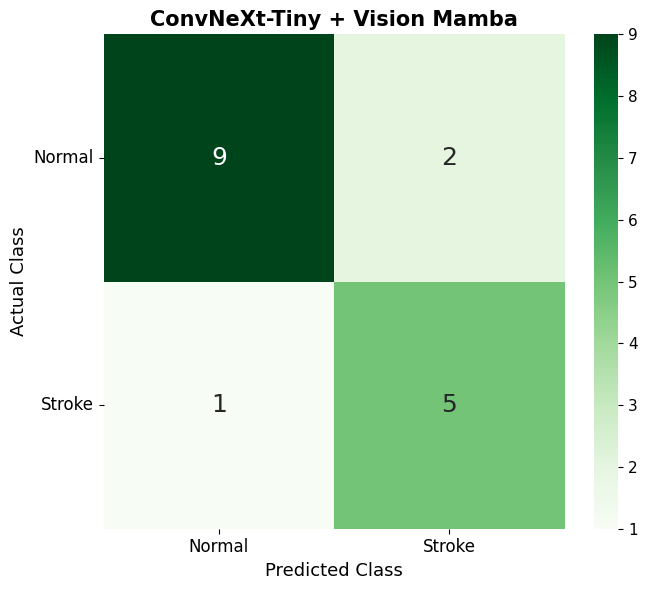

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ----- Evaluate on the patient-level test set -----
results, y_true, y_pred, y_prob = evaluate_model(
    model,
    test_df,
    batch_size=batch_size
)

# ----- Confusion Matrix -----
cm = confusion_matrix(y_true, y_pred)

# Binary classification:
# Normal = 0
# Stroke = 1
TN, FP, FN, TP = cm.ravel()

# ----- Calculate metrics using Stroke as positive class -----
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0

recall = TP / (TP + FN) if (TP + FN) > 0 else 0

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else 0
)

#specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

# ROC-AUC
try:
    roc_auc = roc_auc_score(y_true, y_prob)
except:
    # If y_prob has two columns, use probability of Stroke
    roc_auc = roc_auc_score(y_true, y_prob[:, 1])

# PRINT OUTPUT


print("=" * 60)
print("ConvNeXt-Tiny + Vision Mamba")
print("=" * 60)

print("Confusion Matrix:")
print(cm)

print(f"Accuracy    = {accuracy * 100:.2f}%")
print(f"Precision   = {precision * 100:.4f}%")
print(f"Recall      = {recall * 100:.2f}%")
print(f"F1-Score    = {f1 * 100:.2f}%")
print(f"ROC-AUC = {roc_auc:.4f}%")




# PLOT CONFUSION MATRIX


fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Greens")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Normal", "Stroke"], fontsize=12)
ax.set_yticklabels(["Normal", "Stroke"], fontsize=12)

ax.set_xlabel("Predicted Class", fontsize=13)
ax.set_ylabel("Actual Class", fontsize=13)

ax.set_title("ConvNeXt-Tiny + Vision Mamba", fontsize=18, fontweight="bold")

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        text_color = "white" if cm[i, j] > cm.max() / 2 else "black"

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color=text_color,
            fontsize=16
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()




